In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, log_loss
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.benchmark as benchmark
import torch._dynamo
from torchinfo import summary
import seaborn as sns
from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch
from torch import Tensor
from torch.optim import Optimizer
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, log_loss
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.benchmark as benchmark
import torch._dynamo
from torchinfo import summary
import seaborn as sns
from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch
from torch import Tensor
from torch.optim import Optimizer
# Standard Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Scikit-learn Libraries
from sklearn.datasets import fetch_covtype
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, log_loss
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# PyTorch Core
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch import Tensor
from torch.autograd import Function
from torch.utils.checkpoint import checkpoint

# PyTorch Utilities
import torch.utils.benchmark as benchmark
import torch._dynamo
from torch.optim import Optimizer

# PyTorch Model Utilities
from torchinfo import summary
import gc


In [12]:
def zeropower_via_newtonschulz5(G: Tensor, steps: int) -> Tensor:
    assert G.ndim >= 2
    a, b, c = 3.4445, -4.7750, 2.0315
    X = G.clone().float()
    if G.size(-2) > G.size(-1):
        X = X.mT
    X = X / (X.norm(dim=(-2, -1), keepdim=True) + 1e-7)
    for _ in range(steps):
        A = X @ X.mT
        B = b * A + c * A @ A
        X = a * X + B @ X
    if G.size(-2) > G.size(-1):
        X = X.mT
    return X

class Muon(Optimizer):
    def __init__(self, params, lr=0.02, weight_decay=0.01, momentum=0.95, nesterov=True, ns_steps=5):
        defaults = dict(lr=lr, weight_decay=weight_decay, momentum=momentum, nesterov=nesterov, ns_steps=ns_steps)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self):
        for group in self.param_groups:
            lr = group["lr"]
            weight_decay = group["weight_decay"]
            momentum = group["momentum"]
            nesterov = group["nesterov"]
            ns_steps = group["ns_steps"]

            for p in group["params"]:
                if p.grad is None:
                    continue
                g = p.grad.data

                if g.ndim < 2:
                    continue  # skip scalars, biases, etc.

                state = self.state[p]
                if "momentum_buffer" not in state:
                    state["momentum_buffer"] = torch.zeros_like(g)

                buf = state["momentum_buffer"]
                buf.mul_(momentum).add_(g)

                if nesterov:
                    g = g + momentum * buf
                else:
                    g = buf

                if g.ndim == 4:
                    g = g.view(g.size(0), -1)

                g = zeropower_via_newtonschulz5(g, steps=ns_steps).view_as(p)

                p.mul_(1 - lr * weight_decay)
                p.add_(g, alpha=-lr)

In [13]:
torch._dynamo.config.cache_size_limit = 16

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
device = "cpu"

In [14]:
df = sns.load_dataset('diamonds')
df = df[['carat', 'depth', 'table', 'price', 'x', 'y', 'z', 'cut']]

df['cut'] = (df['cut'] == 'Ideal').astype(int)

X = df.drop('cut', axis=1)
y = df['cut']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long).to(device)

print(X.shape)
print(y.shape)

ideal_percentage = df['cut'].mean() * 100
print(f"Percentage of diamonds with 'Ideal' cut: {ideal_percentage:.2f}%")

model = LogisticRegression(penalty='l2', C=0.001, max_iter=10000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

y_pred_proba = model.predict_proba(X_test)
loss = log_loss(y_test, y_pred_proba)

print(f"Test Accuracy: {accuracy * 100:.2f}%")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Ideal', 'Ideal']))
print(model.coef_)
print(f"Log Loss: {loss:.6f}")

(53940, 7)
(53940,)
Percentage of diamonds with 'Ideal' cut: 39.95%
Test Accuracy: 79.30%
Classification Report:
              precision    recall  f1-score   support

   Not Ideal       0.82      0.85      0.83      6496
       Ideal       0.75      0.71      0.73      4292

    accuracy                           0.79     10788
   macro avg       0.79      0.78      0.78     10788
weighted avg       0.79      0.79      0.79     10788

[[-0.15688782 -0.46189194 -1.57368125  0.22509094 -0.08309788 -0.03167662
  -0.08671039]]
Log Loss: 0.451068


/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered

In [15]:
def train(model, criterion, optimizers, epochs):
    print(summary(model, input_data=X_train_tensor))

    # torch.set_printoptions(threshold=float('inf'))
    # for name, param in model.named_parameters():
    #     print(name)
    #     print(param)

    # @torch._dynamo.explain
    # def run_model(x):
    #     return model(x)

    # run_model(X_train_tensor) # type: ignore

    best_test_loss = float('inf')

    train_losses = []
    test_losses = []

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

    schedulers = [
        torch.optim.lr_scheduler.LinearLR(opt, start_factor=1.0, end_factor=0.05, total_iters=epochs)
        for opt in optimizers
    ]

    for epoch in range(1, epochs + 1):
        model.train()
        for opt in optimizers:
            opt.zero_grad()

        train_outputs = model(X_train_tensor)
        train_loss = criterion(train_outputs, y_train_tensor)
        train_loss.backward()

        for opt in optimizers:
            opt.step()

        model.eval()
        with torch.no_grad():
            test_outputs = model(X_test_tensor)
            test_loss = criterion(test_outputs, y_test_tensor)
            test_predictions = torch.argmax(test_outputs, dim=1)
            test_accuracy = (test_predictions == y_test_tensor).sum().item() / y_test_tensor.size(0)

        train_losses.append(train_loss.item())
        test_losses.append(test_loss.item())

        if test_loss.item() < best_test_loss:
            best_test_loss = test_loss.item()

        for scheduler in schedulers:
            scheduler.step()

        if epoch % 100 == 0:
            print(f"Epoch {epoch}/{epochs}, Train Loss: {train_loss.item():.8f}, Test Loss: {test_loss.item():.8f}, Test Accuracy: {test_accuracy:.4f}")

    if torch.cuda.is_available():
        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

        print(f"[GPU] Peak memory allocated: {torch.cuda.max_memory_allocated() / 1024 ** 2:.2f} MB")
        print(f"[GPU] Peak memory reserved: {torch.cuda.max_memory_reserved() / 1024 ** 2:.2f} MB")

    print()
    print(f"Lowest Test Loss: {best_test_loss:.8f}")

    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(test_losses, label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Test Loss Over Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()

In [37]:
class CReLUFunction(Function):
    @staticmethod
    def forward(ctx, input):
        ctx.save_for_backward(input)
        pos = torch.relu(input)
        neg = torch.relu(-input)
        return torch.cat((pos, neg), dim=1)

    @staticmethod
    def backward(ctx, grad_output):
        input, = ctx.saved_tensors

        channels = input.shape[1]
        grad_pos = grad_output[:, :channels]
        grad_neg = grad_output[:, channels:]

        grad_input = grad_pos * (input > 0).float() - grad_neg * (input < 0).float()

        return grad_input


class CReLU(nn.Module):
    def forward(self, x):
        return CReLUFunction.apply(x)


class DiamondNN(nn.Module):
    def __init__(self, n, num_layers=12):
        super().__init__()
        self.activation = CReLU()

        self.lns = nn.ModuleList()
        self.linears1 = nn.ModuleList()
        self.linears2 = nn.ModuleList()

        for i in range(num_layers):
            dim = n
            self.lns.append(nn.LayerNorm(dim))
            self.linears1.append(nn.Linear(dim * 2, dim * 2))
            self.linears2.append(nn.Linear(dim * 4, dim))

        self.final = nn.Linear(n, 2)
        with torch.no_grad():
            nn.init.zeros_(self.final.weight)
            nn.init.zeros_(self.final.bias)

    def forward(self, x):
        for ln, linear1, linear2 in zip(self.lns, self.linears1, self.linears2):
            residual = x
            x = ln(x)
            x = self.activation(x)
            x = linear1(x)
            x = self.activation(x)
            x = residual + linear2(x)

        return self.final(x)

In [38]:
model = torch.compile(DiamondNN(n=X.shape[1]).to(device))
criterion = nn.CrossEntropyLoss()

muon_params = []
adamw_params = []

for name, param in model.named_parameters():
    if (param.ndim >= 2):
        muon_params.append(param)
    else:
        adamw_params.append(param)

print("Muon parameters:")
for p in muon_params:
    print(p.shape)

print()
print("AdamW parameters:")
for p in adamw_params:
    print(p.shape)

optimizers = [
    Muon(muon_params, lr=0.01, weight_decay=0.0),
    optim.AdamW(adamw_params, weight_decay=0.0)
]

Muon parameters:
torch.Size([14, 14])
torch.Size([14, 14])
torch.Size([14, 14])
torch.Size([14, 14])
torch.Size([14, 14])
torch.Size([14, 14])
torch.Size([14, 14])
torch.Size([14, 14])
torch.Size([14, 14])
torch.Size([14, 14])
torch.Size([14, 14])
torch.Size([14, 14])
torch.Size([7, 28])
torch.Size([7, 28])
torch.Size([7, 28])
torch.Size([7, 28])
torch.Size([7, 28])
torch.Size([7, 28])
torch.Size([7, 28])
torch.Size([7, 28])
torch.Size([7, 28])
torch.Size([7, 28])
torch.Size([7, 28])
torch.Size([7, 28])
torch.Size([2, 7])

AdamW parameters:
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([14])
torch.Size([14])
torch.Size([14])
torch.Size([14])
t

Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─DiamondNN: 1-1                         [43152, 2]                --
│    └─ModuleList: 2-56                  --                        (recursive)
│    │    └─LayerNorm: 3-1               [43152, 7]                14
│    └─CReLU: 2-2                        [43152, 14]               --
│    └─ModuleList: 2-58                  --                        (recursive)
│    │    └─Linear: 3-2                  [43152, 14]               210
│    └─CReLU: 2-4                        [43152, 28]               --
│    └─ModuleList: 2-60                  --                        (recursive)
│    │    └─Linear: 3-3                  [43152, 7]                203
│    └─ModuleList: 2-56                  --                        (recursive)
│    │    └─LayerNorm: 3-4               [43152, 7]                14
│    └─CReLU: 2-7                        [43152

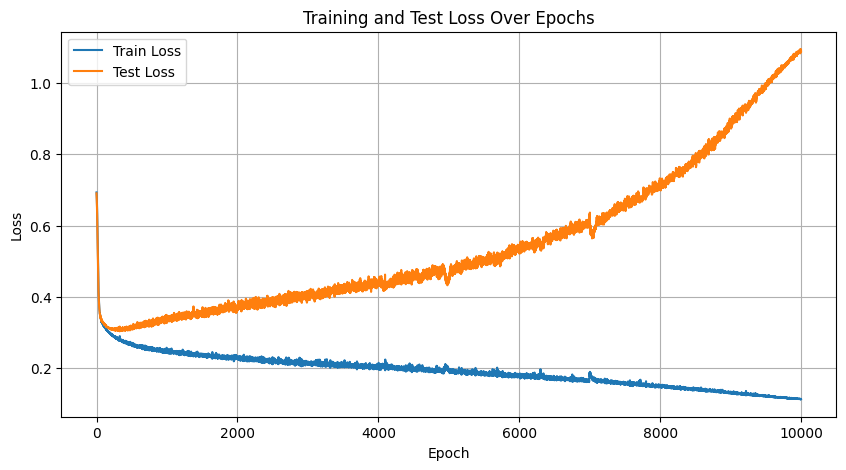

In [39]:
train(model, criterion, optimizers, epochs=10000)

W0521 14:38:01.103000 38110 torch/_dynamo/convert_frame.py:906] [5/32] torch._dynamo hit config.cache_size_limit (16)
W0521 14:38:01.103000 38110 torch/_dynamo/convert_frame.py:906] [5/32]    function: 'hook' (/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/torchinfo/torchinfo.py:592)
W0521 14:38:01.103000 38110 torch/_dynamo/convert_frame.py:906] [5/32]    last reason: 5/16: Cache line invalidated because L['module'] got deallocated
W0521 14:38:01.103000 38110 torch/_dynamo/convert_frame.py:906] [5/32] To log all recompilation reasons, use TORCH_LOGS="recompiles".
W0521 14:38:01.103000 38110 torch/_dynamo/convert_frame.py:906] [5/32] To diagnose recompilation issues, see https://pytorch.org/docs/main/torch.compiler_troubleshooting.html.


Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─DiamondNN: 1-1                         [43152, 2]                --
│    └─ModuleList: 2-16                  --                        (recursive)
│    │    └─LayerNorm: 3-1               [43152, 7]                14
│    └─CReLU: 2-2                        [43152, 14]               --
│    └─ModuleList: 2-18                  --                        (recursive)
│    │    └─Linear: 3-2                  [43152, 14]               210
│    └─CReLU: 2-4                        [43152, 28]               --
│    └─ModuleList: 2-20                  --                        (recursive)
│    │    └─Linear: 3-3                  [43152, 7]                203
│    └─ModuleList: 2-16                  --                        (recursive)
│    │    └─LayerNorm: 3-4               [43152, 7]                14
│    └─CReLU: 2-7                        [43152

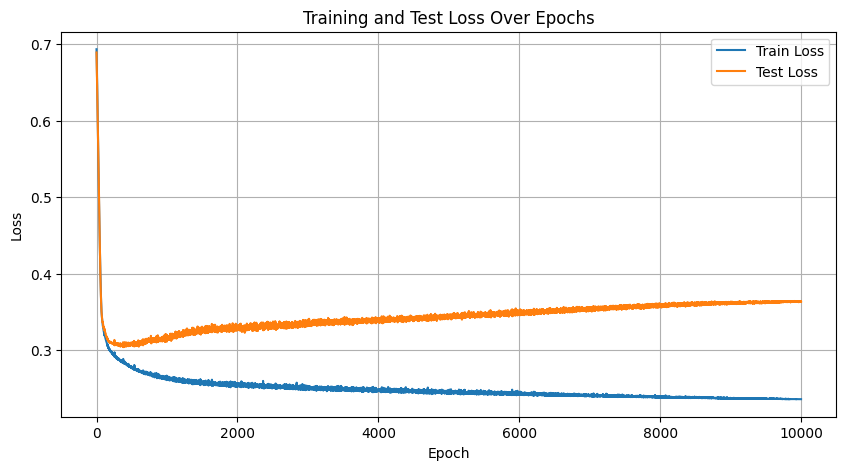

In [31]:
train(model, criterion, optimizers, epochs=10000)

In [40]:
class DiamondNN(nn.Module):
    def __init__(self, n, num_layers=12):
        super().__init__()
        self.activation = nn.ReLU()

        self.lns = nn.ModuleList()
        self.linears1 = nn.ModuleList()
        self.linears2 = nn.ModuleList()

        for i in range(num_layers):
            dim = n
            self.lns.append(nn.LayerNorm(dim))
            self.linears1.append(nn.Linear(dim, dim * 4))
            self.linears2.append(nn.Linear(dim * 4, dim))

        self.final = nn.Linear(n, 2)
        with torch.no_grad():
            nn.init.zeros_(self.final.weight)
            nn.init.zeros_(self.final.bias)

    def forward(self, x):
        for ln, linear1, linear2 in zip(self.lns, self.linears1, self.linears2):
            residual = x
            x = ln(x)
            x = linear1(x)
            x = self.activation(x)
            x = residual + linear2(x)

        return self.final(x)

In [41]:
model = torch.compile(DiamondNN(n=X.shape[1]).to(device))
criterion = nn.CrossEntropyLoss()

muon_params = []
adamw_params = []

for name, param in model.named_parameters():
    if (param.ndim >= 2):
        muon_params.append(param)
    else:
        adamw_params.append(param)

print("Muon parameters:")
for p in muon_params:
    print(p.shape)

print()
print("AdamW parameters:")
for p in adamw_params:
    print(p.shape)

optimizers = [
    Muon(muon_params, lr=0.01, weight_decay=0.0),
    optim.AdamW(adamw_params, weight_decay=0.0)
]

Muon parameters:
torch.Size([28, 7])
torch.Size([28, 7])
torch.Size([28, 7])
torch.Size([28, 7])
torch.Size([28, 7])
torch.Size([28, 7])
torch.Size([28, 7])
torch.Size([28, 7])
torch.Size([28, 7])
torch.Size([28, 7])
torch.Size([28, 7])
torch.Size([28, 7])
torch.Size([7, 28])
torch.Size([7, 28])
torch.Size([7, 28])
torch.Size([7, 28])
torch.Size([7, 28])
torch.Size([7, 28])
torch.Size([7, 28])
torch.Size([7, 28])
torch.Size([7, 28])
torch.Size([7, 28])
torch.Size([7, 28])
torch.Size([7, 28])
torch.Size([2, 7])

AdamW parameters:
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([7])
torch.Size([28])
torch.Size([28])
torch.Size([28])
torch.Size([28])
torch.Size([2

Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─DiamondNN: 1-1                         [43152, 2]                --
│    └─ModuleList: 2-45                  --                        (recursive)
│    │    └─LayerNorm: 3-1               [43152, 7]                14
│    └─ModuleList: 2-46                  --                        (recursive)
│    │    └─Linear: 3-2                  [43152, 28]               224
│    └─ReLU: 2-3                         [43152, 28]               --
│    └─ModuleList: 2-48                  --                        (recursive)
│    │    └─Linear: 3-3                  [43152, 7]                203
│    └─ModuleList: 2-45                  --                        (recursive)
│    │    └─LayerNorm: 3-4               [43152, 7]                14
│    └─ModuleList: 2-46                  --                        (recursive)
│    │    └─Linear: 3-5               

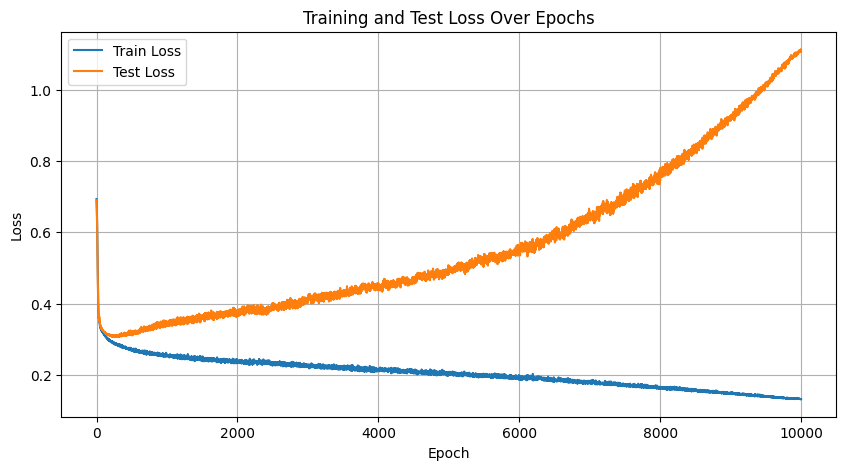

In [42]:
train(model, criterion, optimizers, epochs=10000)

Layer (type:depth-idx)                   Output Shape              Param #
OptimizedModule                          [43152, 2]                --
├─DiamondNN: 1-1                         [43152, 2]                --
│    └─ModuleList: 2-13                  --                        (recursive)
│    │    └─LayerNorm: 3-1               [43152, 7]                14
│    └─ModuleList: 2-14                  --                        (recursive)
│    │    └─Linear: 3-2                  [43152, 28]               224
│    └─ReLU: 2-3                         [43152, 28]               --
│    └─ModuleList: 2-16                  --                        (recursive)
│    │    └─Linear: 3-3                  [43152, 7]                203
│    └─ModuleList: 2-13                  --                        (recursive)
│    │    └─LayerNorm: 3-4               [43152, 7]                14
│    └─ModuleList: 2-14                  --                        (recursive)
│    │    └─Linear: 3-5               

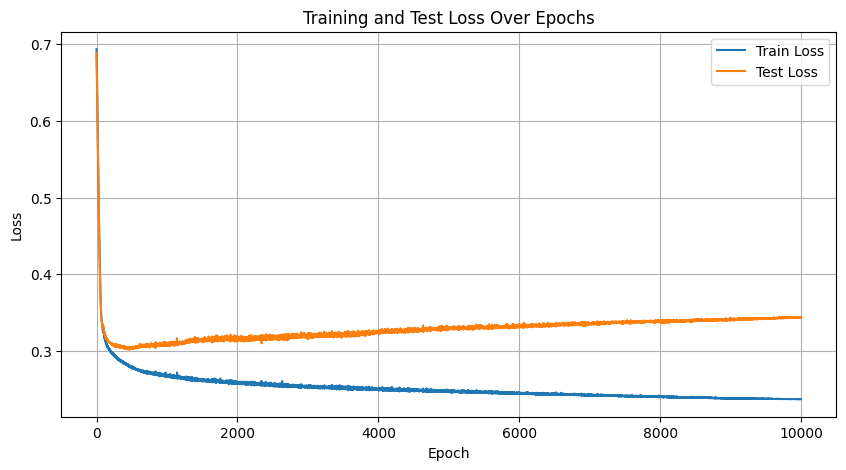

In [34]:
train(model, criterion, optimizers, epochs=10000)